In [1]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

In [2]:
os.makedirs("enhanced", exist_ok=True)

In [3]:
image = cv2.imread("documents/doc1.jpg")

if image is None:
    print("Image not found!")
else:
    print("Image Loaded Successfully")

Image Loaded Successfully


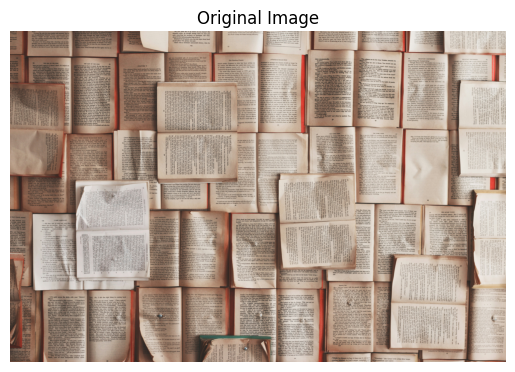

In [4]:
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Original Image")
plt.show()

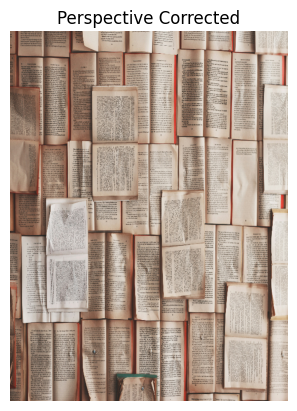

In [15]:
h, w = image.shape[:2]

pts1 = np.float32([
    [40,40],
    [w-40,30],
    [20,h-30],
    [w-20,h-20]
])

pts2 = np.float32([
    [0,0],
    [600,0],
    [0,800],
    [600,800]
])

matrix = cv2.getPerspectiveTransform(pts1, pts2)
corrected = cv2.warpPerspective(image, matrix, (600,800))

# display

plt.imshow(cv2.cvtColor(corrected, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Perspective Corrected")
plt.show()

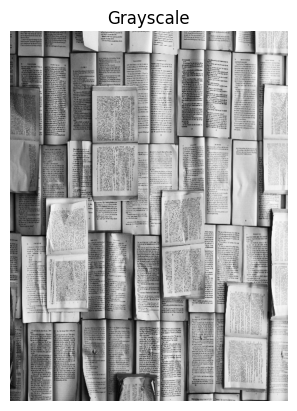

In [16]:
gray = cv2.cvtColor(corrected, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap="gray")
plt.axis("off")
plt.title("Grayscale")
plt.show()

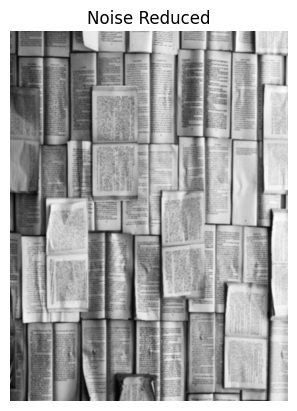

In [17]:
blur = cv2.GaussianBlur(gray,(5,5),0)

plt.imshow(blur,cmap="gray")
plt.axis("off")
plt.title("Noise Reduced")
plt.show()

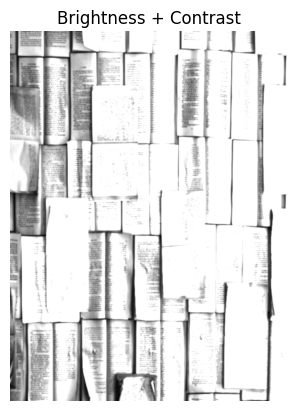

In [18]:
enhanced = cv2.convertScaleAbs(
    blur,
    alpha=1.5,
    beta=30
)

plt.imshow(enhanced,cmap="gray")
plt.axis("off")
plt.title("Brightness + Contrast")
plt.show()

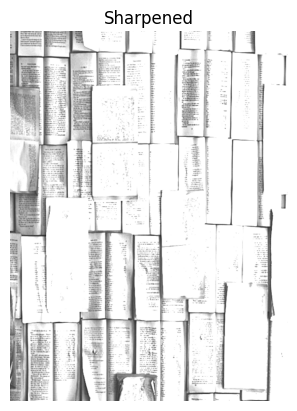

In [19]:
kernel = np.array([
    [0,-1,0],
    [-1,5,-1],
    [0,-1,0]
])

sharp = cv2.filter2D(enhanced,-1,kernel)

plt.imshow(sharp,cmap="gray")
plt.axis("off")
plt.title("Sharpened")
plt.show()

In [20]:
cv2.imwrite("enhanced/doc1_enhanced.jpg", sharp)

print("Saved Successfully")

Saved Successfully


In [21]:
input_folder = "documents"
output_folder = "enhanced"

for file in os.listdir(input_folder):
    if file.lower().endswith((".jpg",".jpeg",".png")):
        path = os.path.join(input_folder,file)
        image = cv2.imread(path)

        if image is None:
            continue

        h,w = image.shape[:2]
        pts1 = np.float32([
            [40,40],
            [w-40,30],
            [20,h-30],
            [w-20,h-20]
        ])

        pts2 = np.float32([
            [0,0],
            [600,0],
            [0,800],
            [600,800]
        ])

        matrix = cv2.getPerspectiveTransform(pts1,pts2)
        corrected = cv2.warpPerspective(image,matrix,(600,800))
        gray = cv2.cvtColor(corrected,cv2.COLOR_BGR2GRAY)
        blur = cv2.GaussianBlur(gray,(5,5),0)
        enhanced = cv2.convertScaleAbs(
            blur,
            alpha=1.5,
            beta=30
        )

        kernel = np.array([
            [0,-1,0],
            [-1,5,-1],
            [0,-1,0]
        ])

        sharp = cv2.filter2D(enhanced,-1,kernel)
        save_path = os.path.join(
            output_folder,
            file
        )

        cv2.imwrite(save_path,sharp)

print("All Images Processed Successfully!")

All Images Processed Successfully!
